# **Day 76: Large Language Models and Foundation Models**
*Module 11 - Advanced Deep Learning*

Large language models (LLMs) are decoder-only Transformers (Day 67) trained to predict the next token on trillions of tokens, then aligned to follow instructions. **Foundation models** generalise the idea: one large model pretrained on broad data, adapted to many tasks. Earth observation now has its own (Prithvi, Clay, SatMAE, SSL4EO), alongside vision-language models and LLM agents that write analysis code.

> Large language models are huge Transformers trained to predict the next word on enormous text collections. Foundation models (including geospatial ones) are pretrained once and then adapted to many tasks through prompts, fine-tuning or retrieval.
>
> *Example:* An LLM can turn a request such as "Sentinel-2 NDVI for Dhanbad in 2024" into working Earth Engine code, which we must still check.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, math, collections, time
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(76); rng = np.random.default_rng(76)

## **1. Language Modelling**
A language model assigns probabilities to sequences: $p(w_1,\dots,w_n) = \prod_t p(w_t\mid w_{<t})$. Training = maximise the likelihood of the next token (cross-entropy, Day 12/14). **Perplexity** $=\exp(\text{mean cross-entropy})$ measures how "surprised" the model is.

Our training text: a small corpus of remote-sensing sentences (generated from templates so nothing is downloaded).

In [2]:
subjects = ["sentinel-2", "landsat", "the radar", "the drone", "modis", "sentinel-1"]
verbs = ["observes", "maps", "measures", "detects", "monitors"]
objects = ["crop health", "flood extent", "forest loss", "urban growth", "soil moisture", "snow cover", "burnt areas", "water quality"]
tails = ["every five days", "at ten metre resolution", "through clouds", "over large regions", "with high accuracy", "across seasons"]
corpus = " ".join(f"{rng.choice(subjects)} {rng.choice(verbs)} {rng.choice(objects)} {rng.choice(tails)}." for _ in range(3000))
chars = sorted(set(corpus)); stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in corpus]); n_tr = int(0.9 * len(data))
train_data, val_data = data[:n_tr], data[n_tr:]
print(f"{len(corpus):,} characters, vocabulary of {len(chars)} characters")
print(corpus[:200])

147,101 characters, vocabulary of 28 characters
the drone monitors urban growth across seasons. the radar detects water quality with high accuracy. sentinel-1 observes crop health at ten metre resolution. landsat measures forest loss across seasons


### Baseline: a bigram (character) model
Predict the next character from the current one only, by counting.

In [3]:
counts = torch.ones(len(chars), len(chars))                          # add-one smoothing
for a, b in zip(train_data[:-1], train_data[1:]): counts[a, b] += 1
P_bigram = counts / counts.sum(1, keepdim=True)
nll = -torch.log(P_bigram[val_data[:-1], val_data[1:]]).mean()
print(f"bigram validation perplexity: {math.exp(nll):.2f} (uniform guessing = {len(chars)})")

bigram validation perplexity: 6.65 (uniform guessing = 28)


## **2. A Tiny GPT From Scratch**
Token embedding + positional embedding -> causal Transformer blocks (Day 67) -> linear head predicting the next token at **every** position.

In [4]:
class CausalBlock(nn.Module):
    def __init__(self, d, heads):
        super().__init__(); self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
    def forward(self, x):
        T = x.shape[1]; mask = torch.triu(torch.ones(T, T, dtype=torch.bool), 1)       # True = not allowed (future)
        h = self.ln1(x); x = x + self.attn(h, h, h, attn_mask=mask, need_weights=False)[0]
        return x + self.mlp(self.ln2(x))

class TinyGPT(nn.Module):
    def __init__(self, V, d=96, heads=4, layers=3, block=64):
        super().__init__(); self.block = block
        self.tok, self.pos = nn.Embedding(V, d), nn.Embedding(block, d)
        self.blocks = nn.Sequential(*[CausalBlock(d, heads) for _ in range(layers)]); self.ln = nn.LayerNorm(d); self.head = nn.Linear(d, V)
    def forward(self, idx):
        h = self.tok(idx) + self.pos(torch.arange(idx.shape[1]))
        return self.head(self.ln(self.blocks(h)))
    @torch.no_grad()
    def generate(self, idx, n_new, temperature=1.0, top_k=None):
        for _ in range(n_new):
            logits = self(idx[:, -self.block:])[:, -1] / temperature
            if top_k: logits[logits < logits.topk(top_k).values[:, -1:]] = -float("inf")
            idx = torch.cat([idx, torch.multinomial(F.softmax(logits, -1), 1)], 1)
        return idx

def get_batch(split, bs=64, block=64):
    d = train_data if split == "train" else val_data; ix = torch.randint(len(d) - block - 1, (bs,))
    return torch.stack([d[i:i + block] for i in ix]), torch.stack([d[i + 1:i + block + 1] for i in ix])

gpt = TinyGPT(len(chars)); opt = torch.optim.AdamW(gpt.parameters(), 3e-3, weight_decay=0.01)
print(f"TinyGPT parameters: {sum(p.numel() for p in gpt.parameters()):,}")
t0 = time.perf_counter(); hist = []
for step in range(1200):
    x, y = get_batch("train"); loss = F.cross_entropy(gpt(x).reshape(-1, len(chars)), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 200 == 0 or step == 1199:
        gpt.eval()
        with torch.no_grad():
            xv, yv = get_batch("val", 256); vl = F.cross_entropy(gpt(xv).reshape(-1, len(chars)), yv.reshape(-1)).item()
        gpt.train(); hist.append((step, loss.item(), vl))
print(f"trained in {time.perf_counter() - t0:.0f}s")
print(pd.DataFrame(hist, columns=["step", "train loss", "val loss"]).assign(val_perplexity=lambda d: np.exp(d["val loss"])).round(3).to_string(index=False))

TinyGPT parameters: 347,260


trained in 65s
 step  train loss  val loss  val_perplexity
    0       3.506     2.986          19.809
  200       0.215     0.215           1.239
  400       0.191     0.204           1.226
  600       0.191     0.197           1.218
  800       0.193     0.198           1.219
 1000       0.194     0.197           1.217
 1199       0.201     0.199           1.220


## **3. Sampling: Temperature and Top-k**
Generation repeatedly samples the next token. **Temperature** < 1 sharpens the distribution (safer, repetitive); > 1 flattens it (creative, error-prone). **Top-k / top-p (nucleus)** sampling restricts choices to the most likely tokens.

In [5]:
gpt.eval(); start = torch.tensor([[stoi[c] for c in "sentinel-2 "]])
for temp in [0.3, 1.0, 2.0]:
    out = gpt.generate(start, 120, temperature=temp)[0]
    print(f"T = {temp}: {''.join(itos[int(i)] for i in out)}\n")

T = 0.3: sentinel-2 maps crop health at ten metre resolution. sentinel-1 maps forest loss across seasons. sentinel-1 monitors forest loss wi



T = 1.0: sentinel-2 maps water quality at ten metre resolution. the drone maps burnt areas with high accuracy. sentinel-1 monitors soil mois



T = 2.0: sentinel-2 detects urban growth oviver large regions. landsat detects observqurnelity landsat observes crop health every five days.



At low temperature the model writes fluent, plausible sentences, and it can **combine** subjects and objects that never occurred together in training. The text is **fluent, not factual**: the model learned which tokens go together, not what is true. This is the root of **hallucination**.

## **4. Scaling Laws and Emergence**
Kaplan et al. (2020) and Hoffmann et al. (2022, "Chinchilla") found that test loss falls as a **power law** in parameters $N$, data $D$ and compute $C$; for a fixed compute budget, the optimal model has roughly **~20 training tokens per parameter**. Some abilities (multi-step arithmetic, instruction following) appear only at scale, although whether they are truly "emergent" depends on the metric (Schaeffer et al., 2023).

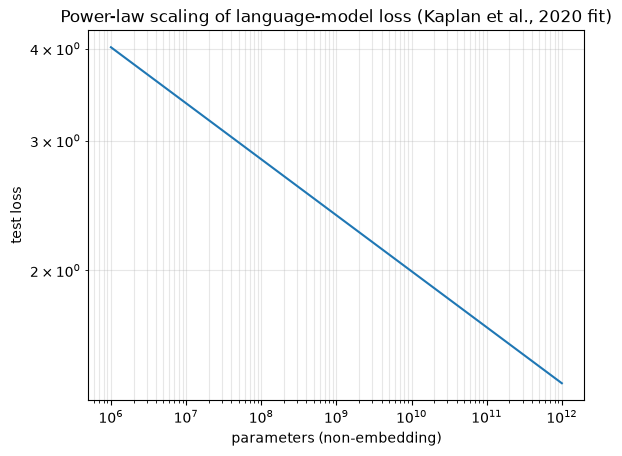

In [6]:
N = np.logspace(6, 12, 50)
loss_N = (8.8e13 / N) ** 0.076                                                       # Kaplan et al. fit (nats/token), illustrative
plt.loglog(N, loss_N); plt.xlabel("parameters (non-embedding)"); plt.ylabel("test loss"); plt.title("Power-law scaling of language-model loss (Kaplan et al., 2020 fit)")
plt.grid(alpha=0.3, which="both"); plt.show()

## **5. From a Pretrained Model to an Assistant**

| Stage | Data | Objective | Result |
|---|---|---|---|
| Pretraining | trillions of tokens of text/code | next-token prediction | broad knowledge, completes text |
| Supervised fine-tuning (SFT) | curated instruction-response pairs | next-token on responses | follows instructions |
| Preference tuning (RLHF / RLAIF / DPO) | human or AI comparisons of responses | reward model + RL (PPO, Day 75) or direct preference optimisation | helpful, honest, harmless style |
| Tool use / agents | traces of tool calls | learn when and how to call tools | can search, run code, use APIs |

## **6. Using LLMs Well: Retrieval-Augmented Generation (RAG)**
An LLM's knowledge is frozen at training time and can be wrong. **RAG** retrieves relevant documents (from our papers, field reports, data documentation) and puts them in the prompt, instructing the model to answer **from the sources** and cite them. Steps: (1) split documents into chunks, (2) embed them, (3) retrieve the chunks most similar to the question, (4) build a grounded prompt.

In [7]:
documents = {
    "S2_doc": "Sentinel-2 carries the MultiSpectral Instrument with 13 bands; 10 m resolution for B2, B3, B4 and B8; revisit of 5 days with two satellites.",
    "S1_doc": "Sentinel-1 is a C-band synthetic aperture radar mission; it images through clouds day and night; VV and VH polarisations are typical over land.",
    "L8_doc": "Landsat 8 and 9 provide 30 m multispectral and 100 m thermal data with a combined 8-day revisit; the archive since 1972 enables long time series.",
    "NDVI_doc": "NDVI equals (NIR - Red) / (NIR + Red); for Sentinel-2 this is (B8 - B4) / (B8 + B4); dense vegetation typically exceeds 0.6.",
    "Flood_doc": "Open water appears dark in SAR backscatter; flood mapping often thresholds Sentinel-1 VV backscatter below about -18 dB, refined with machine learning.",
    "Accuracy_doc": "Map accuracy should be estimated from a probability sample of reference data with stratified estimators of area and accuracy (Olofsson et al., 2014)."}
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(stop_words="english").fit(documents.values()); D = vec.transform(documents.values())

def retrieve(question, k=2):
    sims = (D @ vec.transform([question]).T).toarray().ravel(); order = sims.argsort()[::-1][:k]
    return [(list(documents)[i], list(documents.values())[i], round(float(sims[i]), 3)) for i in order]

def build_prompt(question, k=2):
    ctx = "\n".join(f"[{doc_id}] {text}" for doc_id, text, _ in retrieve(question, k))
    return (f"Answer the question using ONLY the sources below. Cite source ids in brackets. "
            f"If the sources do not contain the answer, say so.\n\nSources:\n{ctx}\n\nQuestion: {question}")

question = "Which mission can map floods under cloud cover, and how is water detected?"
print("retrieved:", [(d, s) for d, _, s in retrieve(question)])
print("\n" + build_prompt(question))

retrieved: [('S1_doc', 0.156), ('Accuracy_doc', 0.141)]

Answer the question using ONLY the sources below. Cite source ids in brackets. If the sources do not contain the answer, say so.

Sources:
[S1_doc] Sentinel-1 is a C-band synthetic aperture radar mission; it images through clouds day and night; VV and VH polarisations are typical over land.
[Accuracy_doc] Map accuracy should be estimated from a probability sample of reference data with stratified estimators of area and accuracy (Olofsson et al., 2014).

Question: Which mission can map floods under cloud cover, and how is water detected?


The prompt is then sent to an LLM: either a hosted model through its provider's API, or an open-weight model running locally. A local example with Hugging Face `transformers` (not executed here, because it downloads a model of several hundred MB):

```python
from transformers import pipeline                      # pip install transformers
generator = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct")   # any instruction-tuned open model
messages = [{"role": "system", "content": "You are a careful remote-sensing assistant. Answer only from the provided sources and cite them."},
            {"role": "user", "content": build_prompt(question)}]
answer = generator(messages, max_new_tokens=300)[0]["generated_text"][-1]["content"]
print(answer)
```
Hosted APIs follow the same pattern: send the system instruction and the prompt, then read the generated text from the response.
Production RAG systems use dense embedding models instead of TF-IDF, a vector database (FAISS, pgvector), chunking with overlap, re-ranking, and evaluation of both retrieval (recall@k) and answer faithfulness.

### Prompting checklist for research use
- Give **context and the goal**, not just a command; provide examples of the desired output format.
- Ask for **sources / reasoning** we can verify; never cite a paper an LLM gives us without finding and reading it.
- For code: run it, test it, read it. LLM-written analysis code is a draft, not a result.
- Do not paste confidential or unpublished data into external services without permission.
- Disclose AI assistance as our target journal requires.

## **7. Parameter-Efficient Fine-Tuning: LoRA**
Full fine-tuning updates billions of weights. **LoRA** (Hu et al., 2022) freezes the pretrained weight $W$ and learns a **low-rank update** $\Delta W = BA$ ($B\in\mathbb R^{d\times r}$, $A\in\mathbb R^{r\times k}$, $r\ll d$): $W' = W + \frac{\alpha}{r}BA$. Far fewer trainable parameters, one small adapter file per task.

In [8]:
class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r=4, alpha=8):
        super().__init__(); self.base = base
        for p in self.base.parameters(): p.requires_grad = False                     # frozen pretrained weights
        self.A = nn.Parameter(torch.randn(r, base.in_features) * 0.01); self.B = nn.Parameter(torch.zeros(base.out_features, r))
        self.scale = alpha / r
    def forward(self, x):
        return self.base(x) + (x @ self.A.T @ self.B.T) * self.scale

# Fine-tune TinyGPT to a new "style": lower-case sentences that always end with "today."
new_corpus = " ".join(f"{rng.choice(subjects)} {rng.choice(verbs)} {rng.choice(objects)} today." for _ in range(800))
new_data = torch.tensor([stoi.get(c, stoi[" "]) for c in new_corpus])
import copy
lora_gpt = copy.deepcopy(gpt)
for p in lora_gpt.parameters(): p.requires_grad = False
for blk in lora_gpt.blocks: blk.mlp[0] = LoRALinear(blk.mlp[0]); blk.mlp[2] = LoRALinear(blk.mlp[2])
trainable = sum(p.numel() for p in lora_gpt.parameters() if p.requires_grad); total = sum(p.numel() for p in lora_gpt.parameters())
print(f"trainable parameters with LoRA: {trainable:,} of {total:,} ({trainable / total:.1%})")
opt = torch.optim.AdamW([p for p in lora_gpt.parameters() if p.requires_grad], 5e-3); lora_gpt.train()
for step in range(300):
    ix = torch.randint(len(new_data) - 65, (32,)); x = torch.stack([new_data[i:i + 64] for i in ix]); y = torch.stack([new_data[i + 1:i + 65] for i in ix])
    loss = F.cross_entropy(lora_gpt(x).reshape(-1, len(chars)), y.reshape(-1)); opt.zero_grad(); loss.backward(); opt.step()
lora_gpt.eval()
print("after LoRA fine-tuning:", "".join(itos[int(i)] for i in lora_gpt.generate(start, 100, temperature=0.3)[0]))

trainable parameters with LoRA: 11,520 of 358,780 (3.2%)


after LoRA fine-tuning: sentinel-2 monitors flood extent today. the drone monitors soil moisture today. sentinel-2 measures snow cover 


## **8. Limits, Evaluation and Responsible Use**

| Risk | What happens | Mitigation |
|---|---|---|
| Hallucination | fluent but false statements, invented citations | RAG with sources; verification; ask for uncertainty |
| Benchmark contamination | test data seen in pretraining inflates scores | held-out, recent or private evaluation sets |
| Bias | reflects biases of training data | evaluate per group (Day 78); human review |
| Privacy / IP | sensitive data sent to external services | local models, data agreements, anonymisation |
| Over-reliance | errors in code or analysis go unnoticed | tests, code review, reproduce results independently |

In [9]:
# Our tiny model "hallucinates" too: ask it to continue a prompt about an object it never saw
prompt = torch.tensor([[stoi[c] for c in "landsat measures glacier "]])
print("".join(itos[int(i)] for i in gpt.generate(prompt, 60, temperature=0.5)[0]), "  <- fluent, unsupported")

landsat measures glacier over large regions. modis monitors crop health at ten metre    <- fluent, unsupported


# **Part 2: Going Deeper - Geospatial Foundation Models**

| Model | Data | Architecture / pretraining | Typical use |
|---|---|---|---|
| **Prithvi-EO 2.0** (NASA & IBM) | Harmonised Landsat-Sentinel (HLS), multi-temporal | ViT, masked autoencoder, temporal + location encodings | flood, burn scar, crop segmentation fine-tuning |
| **Clay** | Sentinel-1/2, Landsat, NAIP, ... | ViT MAE with sensor-aware tokens | embeddings for any location, similarity search |
| **SatMAE / Scale-MAE** | multispectral, multi-scale | MAE with spectral groups / scale-aware encodings | classification, segmentation |
| **SSL4EO-S12 backbones** | 3M Sentinel-1/2 patches | MoCo, DINO, MAE (ResNet, ViT) | transfer learning via TorchGeo |
| **Satellite embeddings** (e.g. Google's AlphaEarth Foundations annual embeddings in Earth Engine) | multi-sensor time series | learned 64-D embedding per 10 m pixel and year | plug-and-play features for classification/regression |
| **Vision-language** (RemoteCLIP, GeoChat) | image-caption pairs | contrastive / instruction-tuned | zero-shot search, captioning, visual question answering |

**How to use them in a research project**
1. Start with **frozen embeddings + a simple model** (logistic regression, RF) as a strong, cheap baseline (Days 63, 70).
2. Then fine-tune (LoRA or full) with spatially separated validation (Day 88).
3. Compare against a well-tuned Random Forest on standard features: foundation models do not always win, especially with good hand-crafted temporal features.
4. Report the exact checkpoint, input normalisation, bands and preprocessing, and compute cost.

## **Practice Problems**
1. Change TinyGPT to 1 layer and 6 layers (same steps). How does validation perplexity change?
2. Implement **top-p (nucleus)** sampling and compare with top-k.
3. Add two new documents to the RAG store and write a question whose answer requires **both** retrieved documents. Does TF-IDF retrieval find them? What would fail?
4. *(Advanced)* Count LoRA parameters as a function of rank r for one 96x384 layer and compare with full fine-tuning.

In [10]:
# Solution 1
for L in [1, 6]:
    torch.manual_seed(0); m = TinyGPT(len(chars), layers=L); o = torch.optim.AdamW(m.parameters(), 3e-3)
    for step in range(600):
        x, y = get_batch("train"); l_ = F.cross_entropy(m(x).reshape(-1, len(chars)), y.reshape(-1)); o.zero_grad(); l_.backward(); o.step()
    m.eval()
    with torch.no_grad(): xv, yv = get_batch("val", 256); print(f"{L} layer(s): val perplexity {math.exp(F.cross_entropy(m(xv).reshape(-1, len(chars)), yv.reshape(-1)).item()):.3f}")
# Solution 2
@torch.no_grad()
def generate_top_p(model, idx, n_new, p=0.9, temperature=1.0):
    for _ in range(n_new):
        probs = F.softmax(model(idx[:, -model.block:])[:, -1] / temperature, -1); sp, si = probs.sort(descending=True)
        keep = sp.cumsum(-1) - sp < p; sp = sp * keep; sp /= sp.sum(-1, keepdim=True)
        idx = torch.cat([idx, si.gather(-1, torch.multinomial(sp, 1))], 1)
    return idx
print("top-p 0.9:", "".join(itos[int(i)] for i in generate_top_p(gpt, start, 100)[0]))
# Solution 3
documents["DEM_doc"] = "The Copernicus DEM provides global elevation at 30 m; slope derived from it is a key landslide conditioning factor."
documents["Rain_doc"] = "Landslides in the Himalaya are commonly triggered by intense monsoon rainfall exceeding local intensity-duration thresholds."
vec = TfidfVectorizer(stop_words="english").fit(documents.values()); D = vec.transform(documents.values())
print(retrieve("What terrain and weather data are needed for landslide susceptibility mapping?", k=3))
# Solution 4
for r in [1, 4, 16, 64]:
    print(f"rank {r:>2}: LoRA params {r * (96 + 384):>6,} vs full {96 * 384:,}")

1 layer(s): val perplexity 1.221


6 layer(s): val perplexity 1.220
top-p 0.9: sentinel-2 maps crop health every five days. sentinel-1 maps forest loss every five days. landsat observes soil
[('DEM_doc', 'The Copernicus DEM provides global elevation at 30 m; slope derived from it is a key landslide conditioning factor.', 0.178), ('Flood_doc', 'Open water appears dark in SAR backscatter; flood mapping often thresholds Sentinel-1 VV backscatter below about -18 dB, refined with machine learning.', 0.144), ('L8_doc', 'Landsat 8 and 9 provide 30 m multispectral and 100 m thermal data with a combined 8-day revisit; the archive since 1972 enables long time series.', 0.112)]
rank  1: LoRA params    480 vs full 36,864
rank  4: LoRA params  1,920 vs full 36,864
rank 16: LoRA params  7,680 vs full 36,864
rank 64: LoRA params 30,720 vs full 36,864


## **Key References**
- Radford, A. et al. (2019). Language models are unsupervised multitask learners. OpenAI technical report (GPT-2).
- Brown, T. et al. (2020). Language models are few-shot learners. *NeurIPS 33*.
- Kaplan, J. et al. (2020). Scaling laws for neural language models. arXiv:2001.08361.
- Hoffmann, J. et al. (2022). Training compute-optimal large language models. *NeurIPS 35* (Chinchilla).
- Ouyang, L. et al. (2022). Training language models to follow instructions with human feedback. *NeurIPS 35*.
- Lewis, P. et al. (2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. *NeurIPS 33*.
- Hu, E. J. et al. (2022). LoRA: Low-rank adaptation of large language models. *ICLR 2022*.
- Bommasani, R. et al. (2021). On the opportunities and risks of foundation models. arXiv:2108.07258.
- Szwarcman, D. et al. (2024). Prithvi-EO-2.0: A versatile multi-temporal foundation model for Earth observation applications. arXiv:2412.02732.